Epoch 0 Loss 0.3398863673210144
Epoch 300 Loss 0.03818076476454735
Epoch 600 Loss 0.024620434269309044
Epoch 900 Loss 0.022422416135668755
Epoch 1200 Loss 0.021909484639763832
Epoch 1500 Loss 0.021199407055974007
Epoch 1800 Loss 0.019444162026047707
Epoch 2100 Loss 0.018728388473391533
Epoch 2400 Loss 0.018161868676543236
Epoch 2700 Loss 0.017832256853580475

===== 欠損点予測 =====

(4,0) 予測=0.5531 真値=0.0000 誤差=0.5531
(6,0) 予測=0.5441 真値=0.0000 誤差=0.5441
(7,0) 予測=0.5413 真値=0.0000 誤差=0.5413
(32,0) 予測=0.5407 真値=0.0000 誤差=0.5407
(34,0) 予測=0.5397 真値=0.0000 誤差=0.5397
(35,0) 予測=0.5389 真値=0.0000 誤差=0.5389
(39,0) 予測=0.5338 真値=0.0000 誤差=0.5338
(40,0) 予測=0.5319 真値=0.0000 誤差=0.5319
(41,0) 予測=0.5299 真値=0.0000 誤差=0.5299
(52,0) 予測=0.5530 真値=0.0000 誤差=0.5530
(54,0) 予測=0.5519 真値=0.0000 誤差=0.5519
(62,0) 予測=0.4990 真値=0.0000 誤差=0.4990
(70,0) 予測=0.4555 真値=0.0000 誤差=0.4555
(80,0) 予測=0.5069 真値=0.0000 誤差=0.5069
(86,0) 予測=0.5455 真値=0.0000 誤差=0.5455
(95,0) 予測=0.4719 真値=0.0000 誤差=0.4719
(98,0) 予測=0.4253 真値=0.0000 誤差=

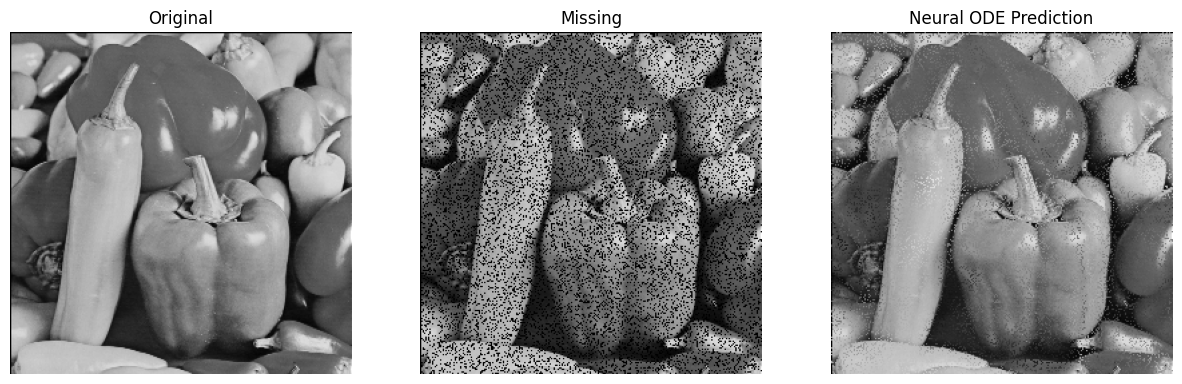

In [12]:
# ============================================
# Neural ODE 画像欠損補間
# 「既知画素は保持し、欠損画素だけ補間」
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# 画像読み込み
# ============================================

# 白黒画像として読み込み
img = Image.open("Images/Peppers.png").convert("L")
#.convert("L")で開いた画像を別の色の形式に変換する命令。"L"はグレースケールを意味する。

# 解像度
img = img.resize((256,256))

# numpy化。imgの画像の各画素値0~256の値に変換して配列にする。
# .astype(np.float32)で便宜上データの種類を32ビット浮動小数点数に変換（0→0.0）
img_array = np.array(img).astype(np.float32)

# 画素値（色の数値：0~255の値）を0〜1正規化
img_array = img_array / 255.0

# ============================================
# 座標作成
# ============================================

#img_array.shape（.shapeはnumpyの属性）でimg_arrayが縦横何マスなのか取得できる
height, width = img_array.shape

# 座標正規化（重要）
# -1~1までwidthの数だけ分割する処理。これでどんな画像のサイズでも中心が０，端が1、－1となり、統一して計算できる
x = np.linspace(-1,1,width)
y = np.linspace(-1,1,height)

X, Y = np.meshgrid(x, y)

# ============================================
# 欠損作成
# ============================================

# np.ones() は、指定されたサイズで「中身がすべて 1 のデータ」を作る関数
# dtype=boolで数字の１ではなくBoolean型（True/False）に変換。１の場合はTrue
# 後の欠損部分をくりぬく処理で便利
mask = np.ones(img_array.shape, dtype=bool)


# 欠損させるピクセル(座標ランダム版)

np.random.seed(42)

# 全画素の５％のピクセル数
num_missing = int(height * width * 0.2)

indices = np.random.choice(
    height * width,
    num_missing,
    replace=False #「重複無し」の意味。一度選んだピクセルの位置は二度とえらばない→正確にかぶりなく5％分の場所を確保できる
)

missing_points = [
    (idx // width, idx % width)
    for idx in indices
]
"""
#ブロック欠損版
missing_points = []

for i in range(100,156):
    for j in range(100,156):
        missing_points.append((i,j))
# 欠損させるピクセル(座標指定版)

missing_points = [

    (20,20),
    (20,21),
    (20,22),

    (21,20),
    (21,21),
    (21,22),

    (22,20),
    (22,21),
    (22,22),

    (40,40),
    (41,41),
    (42,42)

]
"""
# 欠損化
for i,j in missing_points:

    mask[i,j] = False #欠損にしたい座標(i,j)だけをFalseにする

# 欠損画像
img_missing = img_array.copy() #元データを書き換えないためにコピーを作る

img_missing[~mask] = np.nan #欠損指定した座標だけNaNに置き換える

# ============================================
# 学習データ作成
# ============================================

coords = np.stack(
    [X.flatten(), Y.flatten()],
    axis=1
)

targets = img_array.flatten()

mask_flat = mask.flatten()

# 観測点のみ学習
coords_train = coords[mask_flat]

targets_train = targets[mask_flat]

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ============================================
# ODE Function
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,2)

        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc()

        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        h0 = x_input

        t = torch.tensor([0,1]).float()

        out = odeint(
            self.odefunc,
            h0,
            t,
            method='rk4'
        )

        h_final = out[-1]

        z_pred = self.output_layer(h_final)

        return z_pred

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)

    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 300 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ============================================
# 全画素予測
# ============================================

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

with torch.no_grad():

    img_pred = model(
        all_coords_tensor
    ).numpy()

img_pred = img_pred.reshape(
    height,
    width
)

# ============================================
# 欠損部分だけ補間
# ============================================

# 既知画素はそのまま
final_img = img_missing.copy()

# 欠損部分だけNeural ODE予測値を代入
final_img[~mask] = img_pred[~mask]

# ============================================
# 欠損点精度表示
# ============================================

print("\n===== 欠損点予測 =====\n")

missing_y, missing_x = np.where(~mask)

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = final_img[y_val, x_val]

    true_val = img_array[y_val, x_val]

    error = abs(pred_val - true_val)

    print(
        f"({x_val},{y_val}) "
        f"予測={pred_val:.4f} "
        f"真値={true_val:.4f} "
        f"誤差={error:.4f}"
    )

# ============================================
# 欠損点MSE
# ============================================

missing_mse = np.mean(

    (
        img_array[~mask]
        -
        final_img[~mask]

    )**2
)

print("\n==============================")
print("Missing MSE :", missing_mse)
print("==============================")

# ============================================
# 可視化
# ============================================

fig, ax = plt.subplots(1,3, figsize=(15,5))

# 元画像
ax[0].imshow(
    img_array,
    cmap='gray'
)

ax[0].set_title("Original")

# 欠損画像
ax[1].imshow(
    np.nan_to_num(img_missing, nan=0),
    cmap='gray'
)

ax[1].set_title("Missing")

# 補間結果
ax[2].imshow(
    final_img,
    cmap='gray'
)

ax[2].set_title("Neural ODE Prediction")

# 軸OFF
for i in range(3):

    ax[i].axis("off")

plt.show()

In [13]:
img_missing_eval = img_missing.copy()

# NaNを0に置換
img_missing_eval = np.nan_to_num(
    img_missing_eval,
    nan=0
)

missing_img_mse = np.mean(
    (img_array - img_missing_eval) ** 2
)

missing_img_psnr = 10 * np.log10(
    1.0 / missing_img_mse
)

print("Missing Image PSNR :", missing_img_psnr, "dB")


# ============================================
# 全画像PSNR
# ============================================

full_mse = np.mean(
    (img_array - final_img) ** 2
)

if full_mse == 0:
    full_psnr = float("inf")
else:
    full_psnr = 10 * np.log10(1.0 / full_mse)

print("\n==============================")
print("Full Image PSNR :", full_psnr, "dB")
print("==============================")

# 欠損箇所のみのpsnr
missing_mse = np.mean(
    (
        img_array[~mask]
        -
        final_img[~mask]
    ) ** 2
)

if missing_mse == 0:
    missing_psnr = float("inf")
else:
    missing_psnr = 10 * np.log10(1.0 / missing_mse)

print("\n==============================")
print("Missing MSE  :", missing_mse)
print("Missing PSNR :", missing_psnr, "dB")
print("==============================")

import sys
!{sys.executable} -m pip install scikit-image
# ============================================
# Full Image SSIM
# ============================================
from skimage.metrics import structural_similarity as ssim


full_ssim = ssim(
    img_array,
    final_img,
    data_range=1.0
)

print("\n==============================")
print("Full Image SSIM :", full_ssim)
print("==============================")
score, ssim_map = ssim(
    img_array,
    final_img,
    data_range=1.0,
    full=True
)

missing_ssim = np.mean(
    ssim_map[~mask]
)

print("Missing SSIM :", missing_ssim)


Missing Image PSNR : 12.581484 dB

Full Image PSNR : 24.736357 dB

Missing MSE  : 0.016801223
Missing PSNR : 17.746592 dB

Full Image SSIM : 0.7676575153272217
Missing SSIM : 0.760501
